# Concatenating, Joining, and Pivoting Data

There are several ways of answering many questions in this notebook, but try to use the new operations (concatenate, joint/merge, pivot) whenever possible to get practice.

In [19]:
import pandas as pd

## Movie Ratings Data

The Movielens data set (https://dlsun.github.io/pods/data/ml-1m/ ) contains 1 million movie ratings submitted by users. The information about the movies, ratings, and users are stored in three separate files, called `movies.dat`, `ratings.dat`, and `users.dat`. The column names are not included with the data files. Refer to the webpage above for more information.


1\. Read in each of the data files.


(Hint: see the note in the documentation about the delimiter; use the `sep` argument in `read_csv`. If you get an error when reading the `movies.dat` file, try `encoding_errors = "ignore"` in `read_csv`.)

In [20]:
import pandas as pd

base = "https://dlsun.github.io/pods/data/ml-1m/"
movies_url = base + "movies.dat"

movies_df = pd.read_csv(
    base + "movies.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    header=None,
    names=["movie_id", "title", "genre"]
)

ratings_df = pd.read_csv(
    base + "ratings.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    header=None,
    names=["user_id", "movie_id", "rating", "timestamp"]
)

users_df = pd.read_csv(
    base + "users.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    header=None,
    names=["user_id", "gender", "age", "occupation", "zip_code"]
)

display(movies_df.head())
display(ratings_df.head())
display(users_df.head())

,movie_id,title,genre
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


,user_id,gender,age,occupation,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


2\. Which age group tends to give the highest ratings? Create an appropriate summary to answer this question.

(Note the way age is coded in the [REAMDE file](https://dlsun.github.io/pods/data/ml-1m/README.txt).)

In [21]:
# YOUR CODE HERE
rating_users_df = ratings_df.merge(users_df, on = "user_id", how = "left", validate = "many_to_one")

age_label = {1:"<18", 18:"18-24", 25:"25-34", 35:"35-44", 45:"45-49", 50: "50-55", 56:"56+"}

rating_users_df["age_group"] = rating_users_df["age"].map(age_label)

(rating_users_df.groupby("age_group")["rating"]
.agg(n_rating = "size", mean_rating ="mean")
.sort_values("mean_rating", ascending = False)
.reset_index()
)

,age_group,n_rating,mean_rating
0,56+,38780,3.766632
1,50-55,72490,3.714512
2,45-49,83633,3.638062
3,35-44,199003,3.618162
4,<18,27211,3.549520
5,25-34,395556,3.545235
6,18-24,183536,3.507573


3\. Among movies with at least 100 ratings, which movies had the highest average rating? The lowest?

In [22]:
sum_ratings_df = ratings_df.groupby("movie_id")["rating"].agg(n_ratings = "size", mean_ratings = "mean").reset_index()


movies_ratings_df = sum_ratings_df.merge(movies_df,on = "movie_id", how = "left")

more_than_100_ratings_df = movies_ratings_df[movies_ratings_df["n_ratings"] >= 100]

more_than_100_ratings_df

# movies_ratings_100_df = movies_ratings_df

,movie_id,n_ratings,mean_ratings,title,genre
0,1,2077,4.146846,Toy Story (1995),Animation|Children's|Comedy
1,2,701,3.201141,Jumanji (1995),Adventure|Children's|Fantasy
2,3,478,3.016736,Grumpier Old Men (1995),Comedy|Romance
3,4,170,2.729412,Waiting to Exhale (1995),Comedy|Drama
4,5,296,3.006757,Father of the Bride Part II (1995),Comedy
...,...,...,...,...,...
3690,3937,135,2.940741,Runaway (1984),Sci-Fi|Thriller
3699,3946,100,2.260000,Get Carter (2000),Action|Drama|Thriller
3701,3948,862,3.635731,Meet the Parents (2000),Comedy
3702,3949,304,4.115132,Requiem for a Dream (2000),Drama


4\. For each movie, calculate the average rating and the proportion of the ratings that were from users aged 18-24. Make a scatterplot showing the relationship between the average rating and the 18-24 share, with each point representing a movie. (Optional: Use the size of each point to represent the number of users who rated the movie.)

<Axes: xlabel='share_18_24', ylabel='average_rating'>

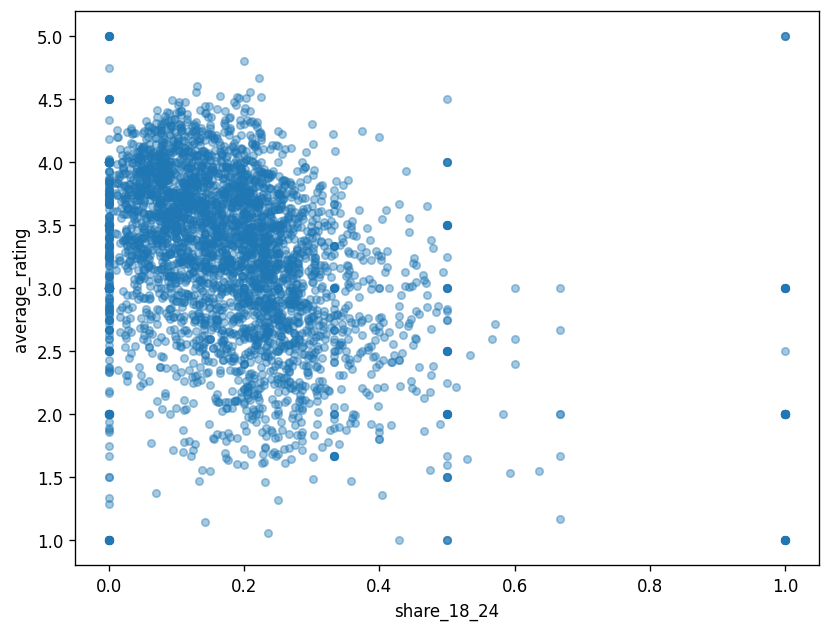

In [23]:
rating_users_df["is_18_24"] = rating_users_df["age_group"] == "18-24"

movie_summary = (
    rating_users_df.groupby("movie_id")
    .agg(
        average_rating=("rating", "mean"),
        share_18_24=("is_18_24", "mean"),
        n_ratings=("rating", "size")
    )
    .reset_index()
)

movie_summary.head()

movie_summary.plot.scatter(
    x="share_18_24",
    y="average_rating",
    alpha=0.4,
    figsize=(8, 6)
)

5\. Calculate the number of ratings by movie. How many of the movies had zero ratings?

(_Hint_: Why is an inner join not sufficient here?)

In [24]:
all_movies = movies_df.merge(
    ratings_by_movie,
    on="movie_id",
    how="left"
)

all_movies["n_ratings"] = all_movies["n_ratings"].fillna(0).astype(int)

n_zero_ratings = (all_movies["n_ratings"] == 0).sum()
n_zero_ratings

all_movies[all_movies["n_ratings"] == 0]

#we need left join because we need to include movies without ratings to count them later. 


,movie_id,title,genre,n_ratings
50,51,Guardian Angel (1994),Action|Drama|Thriller,0
107,109,Headless Body in Topless Bar (1995),Comedy,0
113,115,Happiness Is in the Field (1995),Comedy,0
141,143,Gospa (1995),Drama,0
281,284,New York Cop (1996),Action|Crime,0
...,...,...,...,...
3581,3650,Anguish (Angustia) (1986),Horror,0
3681,3750,Boricua's Bond (2000),Drama,0
3759,3829,Mad About Mambo (2000),Comedy|Romance,0
3786,3856,Autumn Heart (1999),Drama,0


6\. How many movies received both a 1 and a 5 rating? Which movies? How many ratings of each type (1 or 5 stars)? Answer these question by joining two appropriate tables.

In [37]:
# all_movies["both_ratings"] = (all_movies["n_ratings"] == 1) & (all_movies["n_ratings"] == 5)

# all_movies["both_ratings"]

# sum(all_movies["both_ratings"] == "True")

# Need to seperate the 1 ratings and the 5 ratings

one_star = (
    ratings_df[ratings_df["rating"] == 1]
    .groupby("movie_id")
    .size()
    .reset_index(name="n_1_star")
)

five_star = (
    ratings_df[ratings_df["rating"] == 5]
    .groupby("movie_id")
    .size()
    .reset_index(name="n_5_star")
)

both_ratings = (
    one_star
    .merge(five_star, on="movie_id", how="inner")
    .merge(movies_df, on="movie_id", how="left")
)

both_ratings[["movie_id", "title", "n_1_star", "n_5_star"]]

both_ratings.shape[0]

2986